# Intro
This is the "Disaster Tweets" dataset for the public Kaggle contest where they are looking to distinguish between tweets reporting or discussing natural disaster from tweets that simply use words that may trigger any sort of searching by common words like "ablaze" or "fire" that in context makes sense.

target
0    4342
1    3271
Name: count, dtype: int64


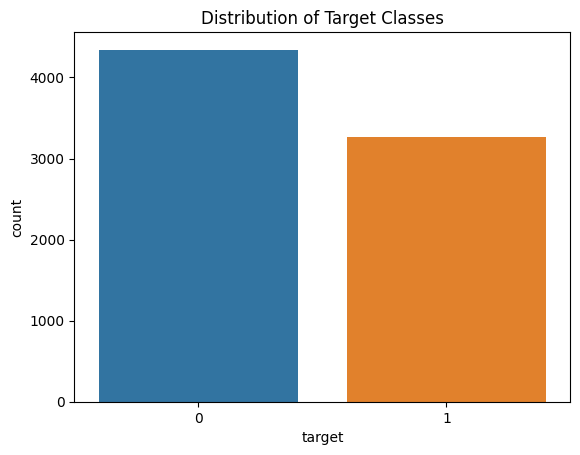

In [56]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

train_df = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test_df = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')

print(train_df['target'].value_counts())
train_df.head()

sns.countplot(x='target', data=train_df)
plt.title('Distribution of Target Classes')
plt.show()

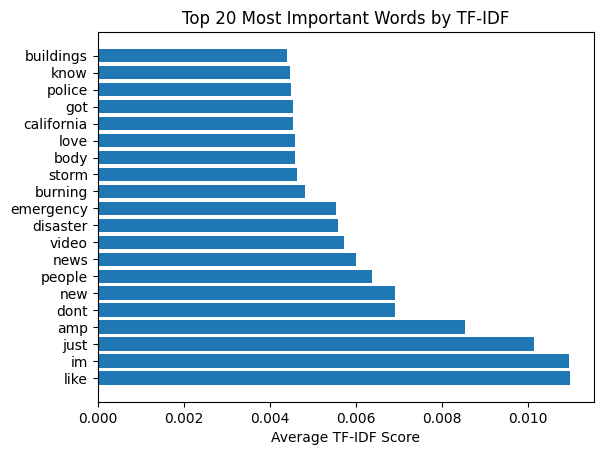

In [57]:
# clean and remove common stopwords to increase effectiveness of data
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s#]', '', text)
    return text.lower()

train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean'] = test_df['text'].apply(clean_text)

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = vectorizer.fit_transform(train_df['text_clean'])

feature_names = vectorizer.get_feature_names_out()
tfidf_array = X_tfidf.toarray()
avg_tfidf = tfidf_array.mean(axis=0)
feature_scores = list(zip(feature_names, avg_tfidf))
sorted_feature_scores = sorted(feature_scores, key=lambda x: x[1], reverse=True)[:20]

words, scores = zip(*sorted_feature_scores)
plt.barh(words, scores)
plt.xlabel('Average TF-IDF Score')
plt.title('Top 20 Most Important Words by TF-IDF')
plt.show()

There are a few words here which I am concerned may be worth adding to the stopwords seeing how common they are, but I can see how many of them may be used to give context to the triggering word so I will leave them be.

In [58]:
X_train_tfidf, X_val_tfidf, y_train, y_val = train_test_split(
    X_tfidf, train_df['target'], test_size=0.2, random_state=42)

# Logistic Regression
logreg_pipeline = Pipeline([
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Hyperparameter tuning
logreg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2']
}

logreg_grid_search = GridSearchCV(logreg_pipeline, logreg_param_grid, cv=3, scoring='f1', verbose=1)
logreg_grid_search.fit(X_train_tfidf, y_train)
logreg_preds = logreg_grid_search.predict(X_val_tfidf)

print("Logistic Regression Classification Report:")
print(classification_report(y_val, logreg_preds))

# Random Forest
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

# Hyperparameter tuning
rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
}

rf_grid_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='f1', verbose=1)
rf_grid_search.fit(X_train_tfidf, y_train)
rf_preds = rf_grid_search.predict(X_val_tfidf)

print("Random Forest Classification Report:")
print(classification_report(y_val, rf_preds))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       874
           1       0.82      0.68      0.74       649

    accuracy                           0.80      1523
   macro avg       0.81      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       874
           1       0.76      0.68      0.72       649

    accuracy                           0.77      1523
   macro avg       0.77      0.76      0.76      1523
weighted avg       0.77      0.77      0.77      1523



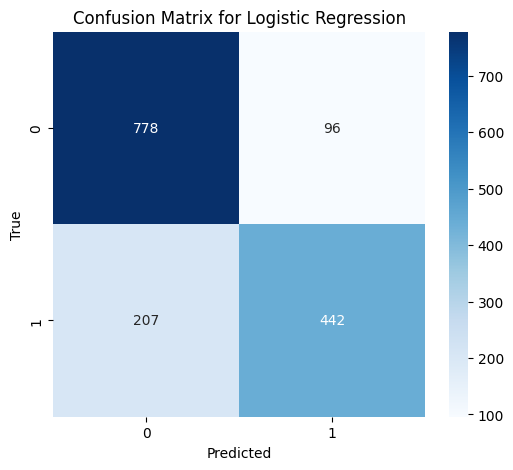

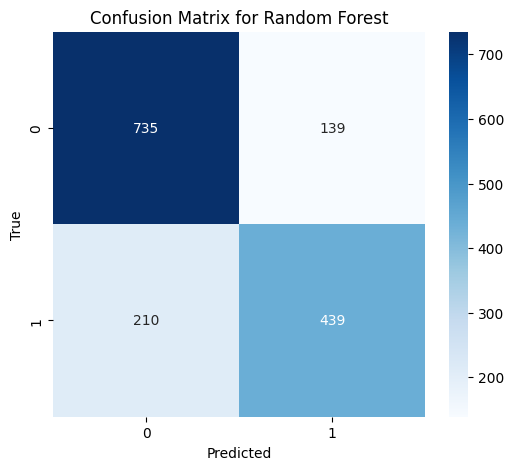

In [59]:
logreg_cm = confusion_matrix(y_val, logreg_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(logreg_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

rf_cm = confusion_matrix(y_val, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Conclusion
So we can see here after using a gridsearch for hyperparameter tuning that logistic regression is a more effective model for making these kinds of predictions, especially seeing as it is a binary supervised training model. The splits in both the results of the random forest and logistic regression reflect the higher number of negative results that was shown to be expected when looking at these tweets as well. As these models show linear regression outperformed the random forest in almost every aspect.